# SCS 3546: Deep Learning
> Assignment 2: Convolutional Neural Nets and Transfer Learning

### Your name & student number:

<pre> Megan Da Costa </pre>

<pre> IdNo </pre>

## Assignment Description

Classifying Flowers using Transfer Learning in Keras

- Download the small flower dataset (http://download.tensorflow.org/example_images/flower_photos.tgzLinks to an external site.). This dataset has 5 classes (Daisy, Dandelion, Rose, Sunflower, and Tulip). Images for each class are stored in its own folder. Note: if clicking on the above link does not trigger a download automatically, try copying the link into your browser.

- The images have different dimensions. Resize all of them to match the pixel dimensions expected by VGG16,  e.g. 224x224 pixels.

- Split images to 80-20% for training and test. Make sure you have the same distribution of flower types between train and test datasets.
Note: your test set should be held out until final evaluation, after you have finished optimizing your model. When trying different hyperparameters, please cut a separate validation split (10-20% of total training set size) from your training data to assess generalization importance. This can be done either manually or by passing the `validation_split` parameter to `model.fit()`.  A single validation split will suffice, you do not need to use full K-fold cross-validation for this assignment.

- Use a VGG16 model (pre-trained on ImageNet) for transfer learning. Remove the top layers (fully connected layers).

- Add your own fully connected layers (example: one with 256 nodes using ‘relu’ activation, and an output layer with 5 nodes and ‘softmax’ activation; the choice is up to you). You will train three different models and compare all three:
  - **Model 1**: First, freeze all layers of VGG16, train only the layers you added on top of it, and evaluate the model. Try your best to improve the model performance, and explain the reason behind any choices you make. You should experiment with different hyperparameters, such as the number of neurons or layers, optimizer type, and so forth. You can also apply regularization, batch normalization, or data augmentation as you see fit. Please show all steps, so we can follow the progression of your improvements to the model. Evaluate your model. You should report training, validation, and test accuracy (all three).
  - **Model 2**: Second, unfreeze the last block of VGG16 (block5), re-train and evaluate the model. You can keep the same set of best hyperparameters that you found while optimizing Model 1, or try new hyperparameters, it's up to you.
  - **Model 3**: Third, unfreeze all the layers and try again. Evaluate your model.

- Compare the accuracy achieved between all three cases. Which one is better and why? Offer an explanation as to why performance is either better or worse in each case.

In [2]:
# setting up the notebook with important libraries
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np

from tensorflow.keras.preprocessing import image
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

os.chdir('/content/drive/MyDrive/datasets/Assignment2_SCS3546')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/datasets/Assignment2_SCS3546


In [3]:
import pathlib

# If there's a nested folder (e.g. 'flower_photos'), update data_dir
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

# Inspect the top-level contents
print("Top-level items:", list(data_dir.glob('*')))

# If there's a nested folder (e.g. 'flower_photos'), update data_dir
nested_dir = data_dir / 'flower_photos'
if nested_dir.is_dir():
    data_dir = nested_dir
    print("Updated data_dir to nested folder:", data_dir)

# Count the images using a glob pattern that covers .jpg files (case-insensitive)
image_count = len(list(data_dir.glob('*/*.[jJ][pP][gG]')))
print(f"Total images: {image_count}")


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Top-level items: [PosixPath('/root/.keras/datasets/flower_photos/flower_photos')]
Updated data_dir to nested folder: /root/.keras/datasets/flower_photos/flower_photos
Total images: 3670


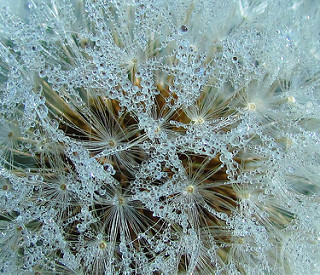

In [4]:
#Testing that folder is loaded correctly
import PIL
roses = list(data_dir.glob('*/*.[jJ][pP][gG]'))
PIL.Image.open(str(roses[0]))

In [5]:
# Train a test split 80/20

train_images = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(224, 224),
  batch_size=32)

test_images = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(224, 224),
  batch_size=32)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


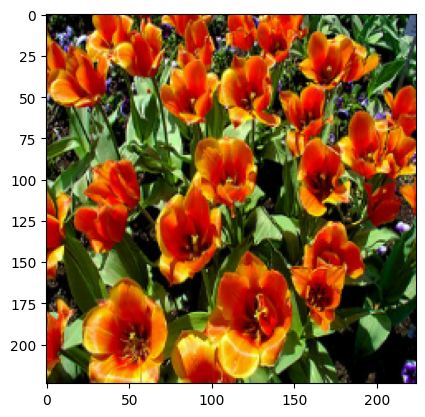

In [6]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
])

for x in train_images.take(1):
 images, labels = x

#pick a random image
image_index=8

# Add the image to a batch
image = tf.expand_dims(images[image_index], 0)

plt.imshow(images[image_index].numpy().astype("uint8"))

In [7]:
# Validation Split

val_batches = int(0.1 * train_images.cardinality().numpy())

validation_split = train_images.take(val_batches)
train_images = train_images.skip(val_batches)

#validation_split = train_images.take(0.1 * train_images.cardinality().numpy())
#train_images = train_images.skip(0.1 * train_images.cardinality().numpy())

base_model = tf.keras.applications.VGG16(weights = "imagenet", include_top=False, input_shape = (224, 224, 3))
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Trainable layers
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer True
1 block1_conv1 True
2 block1_conv2 True
3 block1_pool True
4 block2_conv1 True
5 block2_conv2 True
6 block2_pool True
7 block3_conv1 True
8 block3_conv2 True
9 block3_conv3 True
10 block3_pool True
11 block4_conv1 True
12 block4_conv2 True
13 block4_conv3 True
14 block4_pool True
15 block5_conv1 True
16 block5_conv2 True
17 block5_conv3 True
18 block5_pool True


In [9]:
from keras.models import Sequential, Model
from keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D
from keras import optimizers

In [ ]:
## Model 1: First, freeze all layers of VGG16, train only the layers you added on top of it, and evaluate the model. Try your best to improve the model performance, and explain the reason
##behind any choices you make. You should experiment with different hyperparameters, such as the number of neurons or layers, optimizer type, and so forth. You can also apply regularization,
##batch normalization, or data augmentation as you see fit. Please show all steps, so we can follow the progression of your improvements to the model. Evaluate your model. You should report
##training, validation, and test accuracy (all three).

# Freezing all the layers
for layer in base_model.layers:
    layer.trainable = False

model1 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(5, activation='softmax')
])

# Compiling the model
model1.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

In [ ]:
#fit model1

model1.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 57s 513ms/step - accuracy: 0.6515 - loss: 1.9177 - val_accuracy: 0.8229 - val_loss: 0.6541
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 231ms/step - accuracy: 0.8685 - loss: 0.4558 - val_accuracy: 0.8515 - val_loss: 0.5561
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.9200 - loss: 0.2536 - val_accuracy: 0.8297 - val_loss: 0.5869
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - accuracy: 0.9483 - loss: 0.1529 - val_accuracy: 0.8569 - val_loss: 0.5574
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.9664 - loss: 0.1059 - val_accuracy: 0.8529 - val_loss: 0.5663
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.9851 - loss: 0.0601 - val_accuracy: 0.8651 - val_loss: 0.5593
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.9894 - loss: 0.0476 - val_accuracy: 0.8501 - val_loss: 0.5784
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 252ms/step - accuracy: 0.9902 - loss: 0.0530 - val_accu

In [ ]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,529 (57.65 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 265,228 (1.01 MB)

In [ ]:
train_acc = model1.evaluate(train_images)[1]
val_acc = model1.evaluate(validation_split)[1]
test_acc = model1.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 19s 223ms/step - accuracy: 1.0000 - loss: 0.0020
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 1.0000 - loss: 0.0035
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.8499 - loss: 0.7216
Train accuracy: 1.0
Validation accuracy: 1.0
Test accuracy: 0.8623978495597839


In [ ]:
# Trying an additional layer for model1_b

model1_b = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')
])

# Compiling the model1_b
model1_b.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model1_b

model1_b.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 32s 342ms/step - accuracy: 0.6442 - loss: 1.5852 - val_accuracy: 0.8365 - val_loss: 0.5478
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 255ms/step - accuracy: 0.8668 - loss: 0.3886 - val_accuracy: 0.8488 - val_loss: 0.5396
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.9123 - loss: 0.2703 - val_accuracy: 0.8610 - val_loss: 0.4463
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.9569 - loss: 0.1290 - val_accuracy: 0.8706 - val_loss: 0.4330
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 253ms/step - accuracy: 0.9638 - loss: 0.1115 - val_accuracy: 0.8692 - val_loss: 0.4319
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.9851 - loss: 0.0601 - val_accuracy: 0.8706 - val_loss: 0.4749
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 253ms/step - accuracy: 0.9801 - loss: 0.0620 - val_accuracy: 0.8624 - val_loss: 0.5030
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.9961 - loss: 0.0303 - val_accu

In [ ]:
train_acc = model1_b.evaluate(train_images)[1]
val_acc = model1_b.evaluate(validation_split)[1]
test_acc = model1_b.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.1364 - loss: 3.3564
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.1108 - loss: 3.2132
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.1510 - loss: 3.1391
Train accuracy: 0.1306646466255188
Validation accuracy: 0.1284722238779068
Test accuracy: 0.12942779064178467


In [ ]:
# Trying Dropout for model1_c

model1_c = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compiling the model1_c
model1_c.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model1_c

model1_c.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 29s 308ms/step - accuracy: 0.5065 - loss: 4.2943 - val_accuracy: 0.8134 - val_loss: 0.5949
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.7745 - loss: 0.7478 - val_accuracy: 0.8147 - val_loss: 0.4903
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.8131 - loss: 0.5635 - val_accuracy: 0.8433 - val_loss: 0.4609
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.8365 - loss: 0.4414 - val_accuracy: 0.8365 - val_loss: 0.4393
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.8761 - loss: 0.3732 - val_accuracy: 0.8474 - val_loss: 0.4446
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.8853 - loss: 0.3031 - val_accuracy: 0.8447 - val_loss: 0.4311
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.9046 - loss: 0.2838 - val_accuracy: 0.8624 - val_loss: 0.4059
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 251ms/step - accuracy: 0.9207 - loss: 0.2283 - val_accu

In [ ]:
train_acc = model1_c.evaluate(train_images)[1]
val_acc = model1_c.evaluate(validation_split)[1]
test_acc = model1_c.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 210ms/step - accuracy: 0.2138 - loss: 2.8937
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.1674 - loss: 3.0574
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.2313 - loss: 2.9313
Train accuracy: 0.21185800433158875
Validation accuracy: 0.1701388955116272
Test accuracy: 0.23297002911567688


In [ ]:
## Model 2: Second, unfreeze the last block of VGG16 (block5), re-train and evaluate the model. You can keep the same set of best hyperparameters that you found while optimizing Model 1, or try
## new hyperparameters, it's up to you.

# unFreezing all the layers before layer 5
for layer in base_model.layers[:15]:
    layer.trainable = True

# Model2

model2 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(5, activation='softmax')
])

# Compiling the model2
model2.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model2

model2.fit(train_images, validation_data=test_images, epochs=20)


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.2190 - loss: 4.5504 - val_accuracy: 0.3638 - val_loss: 1.4912
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 559ms/step - accuracy: 0.3819 - loss: 1.4073 - val_accuracy: 0.4782 - val_loss: 1.2495
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 564ms/step - accuracy: 0.4844 - loss: 1.2051 - val_accuracy: 0.5354 - val_loss: 1.1850
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 560ms/step - accuracy: 0.5311 - loss: 1.1720 - val_accuracy: 0.5422 - val_loss: 1.1400
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 560ms/step - accuracy: 0.5541 - loss: 1.1080 - val_accuracy: 0.5545 - val_loss: 1.1227
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 572ms/step - accuracy: 0.5952 - loss: 1.0415 - val_accuracy: 0.5845 - val_loss: 1.0068
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 568ms/step - accuracy: 0.6014 - loss: 1.0008 - val_accuracy: 0.6035 - val_loss: 0.9892
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 565ms/step - accuracy: 0.6304 - loss: 0.9267 - val_accura

In [ ]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,383,057 (115.90 MB)

 Trainable params: 7,767,877 (29.63 MB)

 Non-trainable params: 7,079,424 (27.01 MB)

 Optimizer params: 15,535,756 (59.26 MB)

In [ ]:
train_acc = model2.evaluate(train_images)[1]
val_acc = model2.evaluate(validation_split)[1]
test_acc = model2.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 30s 358ms/step - accuracy: 0.8575 - loss: 0.3969
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.8531 - loss: 0.4634
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.7513 - loss: 0.6741
Train accuracy: 0.8632930517196655
Validation accuracy: 0.8298611044883728
Test accuracy: 0.7656675577163696


In [ ]:
# Trying an additional layer for model2_b

model2_b = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')
])

# Compiling the model2_b
model2_b.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model2_b

model2_b.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 59s 627ms/step - accuracy: 0.6393 - loss: 0.9214 - val_accuracy: 0.7548 - val_loss: 0.6554
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 566ms/step - accuracy: 0.7997 - loss: 0.5393 - val_accuracy: 0.7616 - val_loss: 0.6623
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 560ms/step - accuracy: 0.8203 - loss: 0.4906 - val_accuracy: 0.7575 - val_loss: 0.6675
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 560ms/step - accuracy: 0.8040 - loss: 0.5210 - val_accuracy: 0.7520 - val_loss: 0.7345
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 561ms/step - accuracy: 0.8293 - loss: 0.4811 - val_accuracy: 0.7834 - val_loss: 0.6350
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 561ms/step - accuracy: 0.8731 - loss: 0.3742 - val_accuracy: 0.7834 - val_loss: 0.6415
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 562ms/step - accuracy: 0.8564 - loss: 0.3893 - val_accuracy: 0.7752 - val_loss: 0.7103
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 562ms/step - accuracy: 0.8672 - loss: 0.3848 - val_accu

In [ ]:
train_acc = model2_b.evaluate(train_images)[1]
val_acc = model2_b.evaluate(validation_split)[1]
test_acc = model2_b.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 206ms/step - accuracy: 0.9577 - loss: 0.1239
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.8754 - loss: 0.3662
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.7618 - loss: 0.8945
Train accuracy: 0.9671450257301331
Validation accuracy: 0.875
Test accuracy: 0.7997274994850159


In [ ]:
# Trying Dropout for model2_c

model2_c = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compiling the model2_c
model2_c.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model2_c

model2_c.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 65s 686ms/step - accuracy: 0.6156 - loss: 1.0443 - val_accuracy: 0.7984 - val_loss: 0.7042
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 566ms/step - accuracy: 0.8888 - loss: 0.3104 - val_accuracy: 0.7956 - val_loss: 0.7411
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 561ms/step - accuracy: 0.9120 - loss: 0.2906 - val_accuracy: 0.7902 - val_loss: 0.7425
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 566ms/step - accuracy: 0.9290 - loss: 0.2026 - val_accuracy: 0.7943 - val_loss: 0.9395
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 566ms/step - accuracy: 0.9388 - loss: 0.1904 - val_accuracy: 0.7411 - val_loss: 1.0343
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 565ms/step - accuracy: 0.9294 - loss: 0.2326 - val_accuracy: 0.8052 - val_loss: 0.7531
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 564ms/step - accuracy: 0.9467 - loss: 0.1716 - val_accuracy: 0.7834 - val_loss: 0.8614
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 564ms/step - accuracy: 0.9398 - loss: 0.1673 - val_accu

In [ ]:
train_acc = model2_c.evaluate(train_images)[1]
val_acc = model2_c.evaluate(validation_split)[1]
test_acc = model2_c.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 201ms/step - accuracy: 0.9468 - loss: 0.1940
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.9217 - loss: 0.3882
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.7822 - loss: 1.4525
Train accuracy: 0.9645015001296997
Validation accuracy: 0.9097222089767456
Test accuracy: 0.7929155230522156


In [ ]:
## Model 3: Third, unfreeze all the layers and try again. Evaluate your model.

# unFreezing all the layers
for layer in base_model.layers:
    layer.trainable = True

model3 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(5, activation='softmax')
])

# Compiling the model
model3.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model3

model3.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 65s 677ms/step - accuracy: 0.4128 - loss: 4.4632 - val_accuracy: 0.6921 - val_loss: 0.9133
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 588ms/step - accuracy: 0.7312 - loss: 0.7434 - val_accuracy: 0.7207 - val_loss: 0.8513
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 589ms/step - accuracy: 0.8240 - loss: 0.4797 - val_accuracy: 0.7520 - val_loss: 0.7996
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 586ms/step - accuracy: 0.8563 - loss: 0.4679 - val_accuracy: 0.6308 - val_loss: 1.1019
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 589ms/step - accuracy: 0.7272 - loss: 0.8275 - val_accuracy: 0.7534 - val_loss: 1.0760
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 50s 592ms/step - accuracy: 0.8471 - loss: 0.4139 - val_accuracy: 0.7738 - val_loss: 0.8074
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 50s 594ms/step - accuracy: 0.9118 - loss: 0.2782 - val_accuracy: 0.7602 - val_loss: 0.8444
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 589ms/step - accuracy: 0.9066 - loss: 0.2624 - val_accu

In [ ]:
model3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,541,905 (169.91 MB)

 Trainable params: 14,847,301 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,694,604 (113.28 MB)

In [ ]:
train_acc = model3.evaluate(train_images)[1]
val_acc = model3.evaluate(validation_split)[1]
test_acc = model3.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 203ms/step - accuracy: 0.9669 - loss: 0.1078
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.9032 - loss: 0.3288
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.7594 - loss: 1.0703
Train accuracy: 0.9735649824142456
Validation accuracy: 0.90625
Test accuracy: 0.7806539535522461


In [11]:
# Trying an additional layer for model3_b

model3_b = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')
])

# Compiling the model3_b
model3_b.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model3_b

model3_b.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.2193 - loss: 4.9390 - val_accuracy: 0.3433 - val_loss: 1.5479
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 554ms/step - accuracy: 0.3334 - loss: 1.5073 - val_accuracy: 0.4319 - val_loss: 1.3168
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 561ms/step - accuracy: 0.4343 - loss: 1.2945 - val_accuracy: 0.4850 - val_loss: 1.2338
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 558ms/step - accuracy: 0.4782 - loss: 1.1982 - val_accuracy: 0.5082 - val_loss: 1.1877
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 558ms/step - accuracy: 0.5163 - loss: 1.1523 - val_accuracy: 0.5463 - val_loss: 1.1163
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 560ms/step - accuracy: 0.5583 - loss: 1.0814 - val_accuracy: 0.4918 - val_loss: 1.1987
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 561ms/step - accuracy: 0.5640 - loss: 1.0761 - val_accuracy: 0.5858 - val_loss: 1.0054
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 565ms/step - accuracy: 0.5825 - loss: 1.0128 - val_accura

In [12]:
train_acc = model3_b.evaluate(train_images)[1]
val_acc = model3_b.evaluate(validation_split)[1]
test_acc = model3_b.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 29s 344ms/step - accuracy: 0.7085 - loss: 0.7428
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.7496 - loss: 0.7187
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.6172 - loss: 0.9263
Train accuracy: 0.7031722068786621
Validation accuracy: 0.7083333134651184
Test accuracy: 0.6267030239105225


In [13]:
# Trying Dropout for model3_c

model3_c = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compiling the model3_c
model3_c.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.Adam(learning_rate=0.001), metrics=["accuracy"])

#fit model3_c

model3_c.fit(train_images, validation_data=test_images, epochs=20)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 645ms/step - accuracy: 0.5079 - loss: 1.2385 - val_accuracy: 0.6717 - val_loss: 0.8395
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 568ms/step - accuracy: 0.6364 - loss: 0.9050 - val_accuracy: 0.6771 - val_loss: 0.7974
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 560ms/step - accuracy: 0.6964 - loss: 0.7922 - val_accuracy: 0.6812 - val_loss: 0.7511
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 567ms/step - accuracy: 0.6904 - loss: 0.7612 - val_accuracy: 0.7112 - val_loss: 0.7208
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 564ms/step - accuracy: 0.7047 - loss: 0.7328 - val_accuracy: 0.7248 - val_loss: 0.6861
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 563ms/step - accuracy: 0.7224 - loss: 0.7066 - val_accuracy: 0.7098 - val_loss: 0.7934
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 566ms/step - accuracy: 0.7358 - loss: 0.6787 - val_accuracy: 0.7316 - val_loss: 0.6899
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 47s 564ms/step - accuracy: 0.7589 - loss: 0.6586 - val_accu

In [14]:
train_acc = model3_c.evaluate(train_images)[1]
val_acc = model3_c.evaluate(validation_split)[1]
test_acc = model3_c.evaluate(test_images)[1]

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.8770 - loss: 0.3489
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.7864 - loss: 0.6705
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.7321 - loss: 0.7946
Train accuracy: 0.8935045599937439
Validation accuracy: 0.78125
Test accuracy: 0.7574931979179382


Of the hyperparameters that I decided to test, standard relu activation with 256 nodes and a GlobalAveragePooling2D parameter, adding a layer with fewer nodes, and a dropout to prevent over fitting, it can be seen that Model1 with the standard relu activation had the best accuracy of all the models tested, with a value of 0.862. This would mean the the freezing of layers and single layer addition has the best generalization.

For the Model 1 description of freezing the layers before starting the training, adding a layer caused a significant decrease in accuracy, with a value of 0.129. Adding a dropout in the next test lead to slightly better accuracy of 0.232. The last two models indicating that they are poorly trained

For the Model 2 that unfroze all the layers before block 5 there was an accuracy of arond 0.765. Adding a layer brought it to 0.800. Adding the dropout brought it to 0.793. This could be good models as well, maybe some overfit considering the validation scores were higher.

For the Model 3 that unfroze all the layers, there was an accuracy of 0.781. Adding a layer brought it down to 0.627. Adding the dropout brought it to 0.757. With the validation scores around 0.700 for these models, they could be considered moderate.